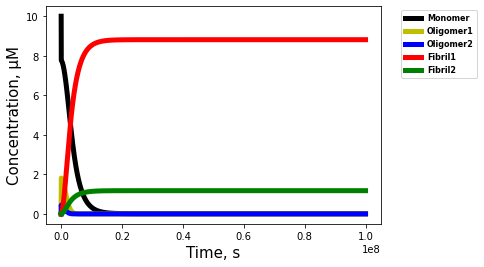

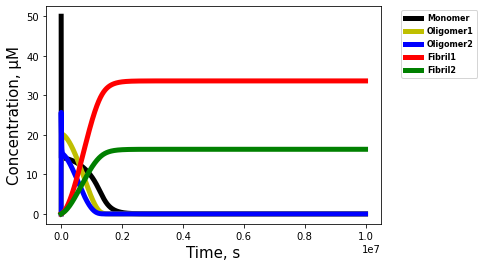

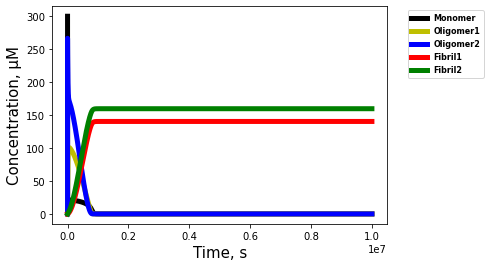

In [19]:
###### Our two-pathway fibrilization model with default parameter.

###### Figure 2A

import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
import pandas as pd
plt.close('all')

for nf2 in [6]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, , 15Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4, nf2, 0.01, 0.01, 10**(-4), 5*10**(-8), 10**(-4), 5*10**(-8), 0, 6, 6 ]       # Free parameters in our model        
    yy=   [0.06,0.08, 0.1, 0.3, 0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,150,200,300,400,600,800,1000,1500,2000,3000,4000,6000,8000,10000] # Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                         # Total discrete point concentration
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        
        #### Aproximate nf1+9 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+9 and truncate th\ high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer number nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer number nucleation
        EE1=  p[4]*EEE1;                                         # 1st-pathway oligomer mass nucleation 
        EE2=  p[5]*EEE2;                                         # 2nd-pathway oligomer mass nucleation 
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])       # 1st-pathway oligomer to fibril seed conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])      # 2nd-pathway oligomer to fibril seed conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril seed conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril seed conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];               # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];              # Growth and shrinking of the 2nd-pathway fibril 
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 
        du[9] = NN2 + GG2
        ################################################################
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        #################################################################
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
    
        return du
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x19=1*10**15; x18=1*10**14; x17=1*10**12; x16=1*10**8; x15=1*10**7; x14=1*10**7; x13=1*10**7;
    tend=[x18, x18, x17, x17, x17, x17,x17,x17,x17,x17,x16,x16,x16,x16,x15,x15,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]

    ###################################################
    # Initialize an empty DataFrame to store the time-step and the corresponding fibril-mass
    df = pd.DataFrame()
   
    #########################################################################
    for i in range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]      ## Introduce the initial condition
        p  = p0                                                                 ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                                        ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                                       ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")                     ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")                    ## Oligomer nucleation rate in 2nd-pathway
        
        # solve rate-mass equations using solve_ivp
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, tend[i])
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t))
        sol_y = np.hstack((sol1.y, sol2.y))
        
        #Plot the time evolution of species
        if  i==10 or i==14 or i==22:
            plt.plot(sol_t, sol_y[0, :],'k',linewidth = 5)
            plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
            plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
            plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
            plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
            #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
            plt.ylabel('Concentration, \u03bcM',fontsize=15)
            plt.xlabel('Time, s',fontsize=15)
            #plt.xscale('log') # uncomment for inset in Fig. 2A
            myleg = plt.legend(['Monomer','Oligomer1','Oligomer2','Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
#             if i==6:
#                 plt.savefig(f'Fig_2A_panel1.eps', dpi=300)
                
#             if i==10:
#                 plt.savefig(f'Fig_2A_panel2.eps', dpi=300)

#             else:
#                 plt.savefig(f'Fig_2A_panel3.eps', dpi=300)
            plt.show()
                
        ############################################################################################################################################36
        # Make dataframe of time and fibril mass for the given discrete initial protein concentrations
        list1 = sol_t                                                                # List of time for the given concentration
        list2 = sol_y[6]+ sol_y[9]                                                   # List of fibril-mass for the given concentration
        temp_df = pd.DataFrame({f'Column{2*i+1}': list1, f'Column{2*i+2}': list2})   # Append the lists to the DataFrame as new columns
        df = pd.concat([df,temp_df],axis=1)                                          # Append the new DataFrame to the main DataFrame
        del list1, list2, sol1 #, sol2, sol3, sol4                                   # Clear memory of the lists to avoid the large memomry need
        gc.collect()
    #################################################################################################################################################37
    # Convert dataframe into numpy array
    array = df.to_numpy()
    #save the numpy array
    np.save(f'Fig_2A.npy', array.T)## keep the name of npy file
    ##################################################################################################################################################38

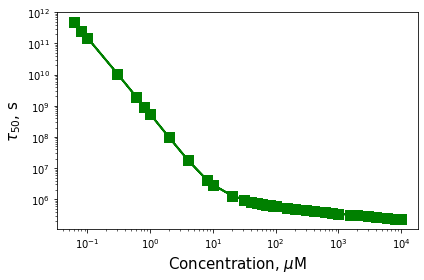

In [27]:
#### Plot the half-time as a function of concentration

#### Figure 2B, row2

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

def removenan(x):
    return np.array([arr[~np.isnan(arr)] for arr in x])

def plot_t50_curve(x, n, Y0, marker='o', label='', cutoff_adjustment = 0.01, color='black'):
    t50 = []
    Y050 = []
    Y00 = [y - cutoff_adjustment for y in Y0]
    for i in range(n):
        cutoff_value = (Y00[i]- cutoff_adjustment) / 2
        fibril_curve = x[2 * i + 1]
        time_curve = x[2 * i]

        for fibril_val, time_val in zip(fibril_curve, time_curve):
            if fibril_val >= cutoff_value:
                t50.append(time_val)
                Y050.append(Y0[i])
                break

    f = interp1d(Y050, t50, kind='cubic')
    t50_interp = f(Y050)

    plt.plot(np.concatenate([Y050, [None], Y050]),np.concatenate([t50, [None], t50_interp]),
        linestyle='-',marker=marker,label=label,linewidth=2,markersize=10,color=color)

    plt.xlabel(r'Concentration, $\mu$M', fontsize=15)
    plt.ylabel(r'$\tau_{50}$, s', fontsize=15)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    return

#### Plot half-time vs concentration
x1 = removenan(np.load('Fig_2A.npy')) # Load and clean data
Y0_common = [0.06,0.08, 0.1, 0.3, 0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,
             90,100,150,200,300,400,600,800,1000,1500,2000,3000,4000,6000,8000,10000]   # Define initial total concentration
#plt.figure(figsize=(6, 5))
plot_t50_curve(x1, n=34, Y0=Y0_common + [10001], marker='s', color='green', cutoff_adjustment=0.01)
#plt.legend()
plt.tight_layout()
#plt.savefig('Fig_2A_row2.eps', dpi=300)
plt.show()

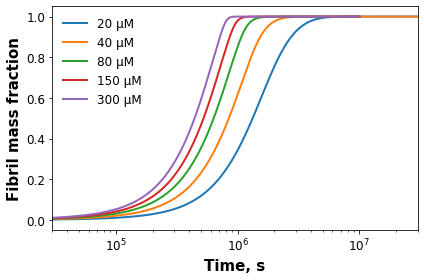

In [26]:
#### Plot the time evolution of total fibril mass at selected concentrations

#### Only for demonstartion

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plotFibrilfractions(x, conc, phi_CR, conc_select):

    # find indices of selected concentrations
    indices = [conc.index(c) for c in conc_select]
    palette = sns.color_palette("tab10", len(indices))

    #plt.figure(figsize=(6,5))
    for j, i in enumerate(indices):
        time_data = x[2*i]
        max_fibril = conc[i] - phi_CR
        fibril_data = x[2*i+1] / max_fibril
        plt.plot(time_data,fibril_data,lw=2,color=palette[j],label=f'{conc[i]} μM')

    plt.xlabel('Time, s', fontsize=15, fontweight='bold')
    plt.ylabel('Fibril mass fraction', fontsize=15, fontweight='bold')
    plt.xscale('log')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlim(3e4,3e7)
    plt.legend(frameon=False, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    
#### Plot
conc = [0.06,0.08, 0.1, 0.3, 0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,
             90,100,150,200,300,400,600,800,1000,1500,2000,3000,4000,6000,8000,10000] 
conc_select = [20, 40, 80, 150, 300]

data = removenan(np.load('Fig_2A.npy')) # Load and clean data
plotFibrilfractions(data, conc, 0.01, conc_select=conc_select)
plt.show()